# Notebook 3: GPR foreground removal

In this notebook, we will alternatively use GPR for foreground removal

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from meer21cm import MockSimulation
from meer21cm.plot import plot_map
from meer21cm.fg import ForegroundSimulation
from meer21cm.util import pca_clean
from gpr import *
from nautilus import Sampler, Prior
from scipy import optimize
from meer21cm.util import redshift_to_freq

In [2]:
import sys
import os
import importlib
#import functions # Replace with your actual file name
#importlib.reload(functions)
#from functions import *
from joblib import Parallel, delayed # this is for the multiprocessing but works with Jupyter notebooks
from tqdm import tqdm # this is to create a progress bar when running code 
import time

First, let us go back to the foreground and HI signal, and to see the structure of their covariances:

In [3]:
# Generate the mock and foreground signals
mock = MockSimulation(
    survey='meerklass_2021',
    band='L',
    flat_sky=True,
    seed=42,
    omega_hi=5e-4,
    mean_amp_1='average_hi_temp',
    tracer_bias_1=1.0,
)
fgsim = ForegroundSimulation(
    hp_nside=128,
    wproj=mock.wproj,
    num_pix_x=mock.num_pix_x,
    num_pix_y=mock.num_pix_y,
    backend='haslam',
    sp_indx_for_haslam_backend=-2.7,
)
hi_map = mock.propagate_mock_field_to_data(mock.mock_tracer_field_1)
fg_map = fgsim.fg_wcs_cube(mock.nu)


In [6]:
# extract their covariance 
cov_hi, _, _, _, = pca_clean(hi_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)
cov_fg, _, _, _, = pca_clean(fg_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)

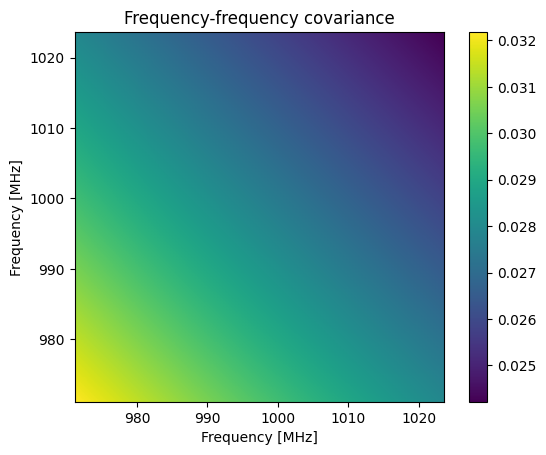

In [9]:
tot_map = hi_map + fg_map
cov_tot, _, eigen_values, _, = pca_clean(tot_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)
plt.imshow(cov_tot,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar()
plt.xlabel('Frequency [MHz]')
plt.ylabel('Frequency [MHz]')
plt.title('Frequency-frequency covariance')
#save_project_plot(plt.gcf(), week_number = 3, filename = "total_map_covariance.pdf")
plt.show()

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week6/tot_fg_hi_covariance.pdf


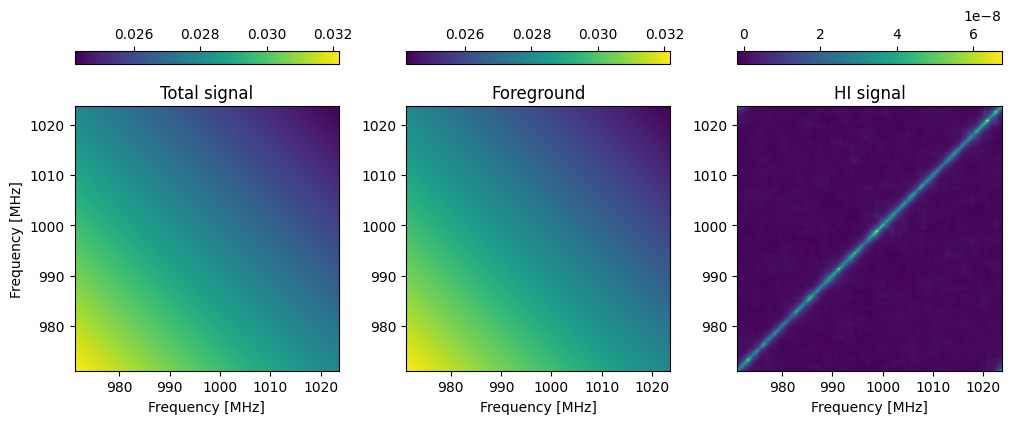

In [23]:
# plot the covariance of the HI and foreground signals
fig,axes = plt.subplots(1,3,figsize=(10,5), layout = "constrained")
im = axes[0].imshow(cov_tot,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='top', pad = 0.05)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title('Total signal')

im = axes[1].imshow(cov_fg,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='top', pad = 0.05)
axes[1].set_xlabel('Frequency [MHz]')
#axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title('Foreground')

im = axes[2].imshow(cov_hi,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='top', pad = 0.05)
axes[2].set_xlabel('Frequency [MHz]')
#axes[2].set_ylabel('Frequency [MHz]')
axes[2].set_title('HI signal')

save_project_plot(plt.gcf(), week_number = 6, filename = "tot_fg_hi_covariance.pdf")
plt.show()


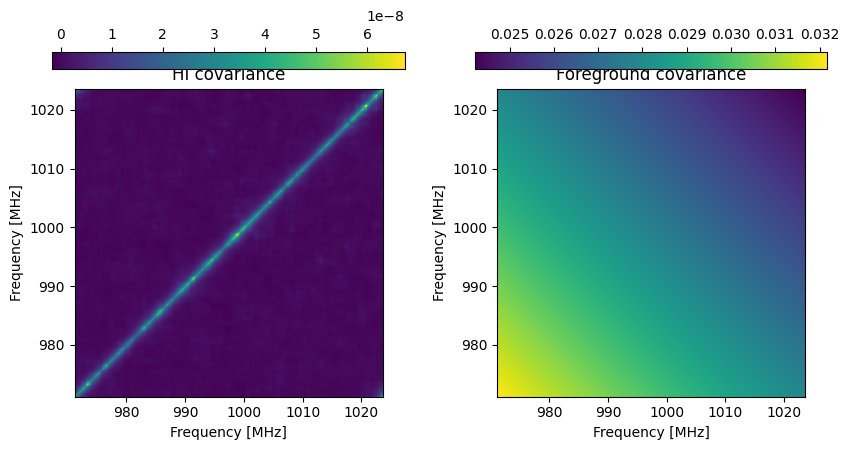

In [11]:
# plot the covariance of the HI and foreground signals
fig,axes = plt.subplots(1,2,figsize=(10,5))
im = axes[0].imshow(cov_hi,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='top')
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title('HI covariance')

im = axes[1].imshow(cov_fg,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='top')
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title('Foreground covariance')
plt.show()

So we want two kernels that represent these two shown above. For example, let us check the exponential kernel first:

In [6]:
# create two exponential kernals
# one first l = 10, second with l = 100
exp_kern_1 = exponential_kernel(mock.nu/1e6,mock.nu/1e6,1,10)
exp_kern_2 = exponential_kernel(mock.nu/1e6,mock.nu/1e6,1,100)

Text(0.5, 1.0, '$l$ = 100 MHz')

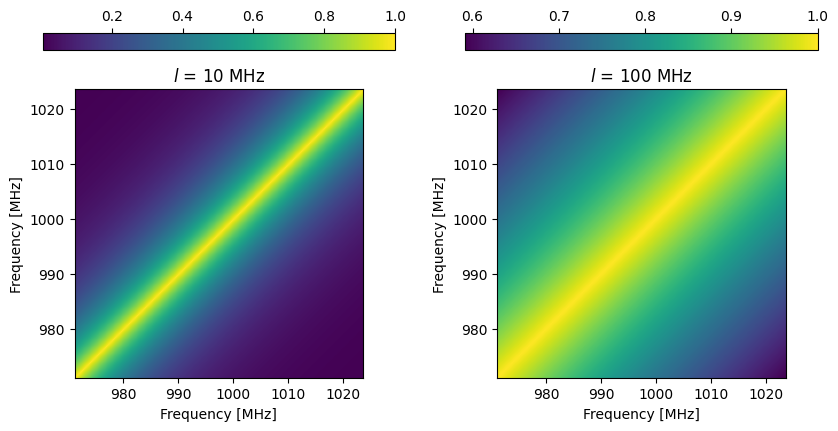

In [7]:
# plot the exponential kernals
fig,axes = plt.subplots(1,2,figsize=(10,5))
im = axes[0].imshow(exp_kern_1,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='top',pad=0.1)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title(r'$l$ = 10 MHz')

im = axes[1].imshow(exp_kern_2,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='top',pad=0.1)
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title(r'$l$ = 100 MHz')


Ignore the amplitude for now, which I set to 1. I simply change $l$, which controls the width of the diagonal stripe as you can see. Larger the l (correlation length), wider the stripe. It is fairly obvious that for HI we need a very small length, say $l=1$ MHz: 

In [8]:
# test a rough estimate of the amplitude of the cov
sigma_hi_kern = np.sqrt(np.diagonal(cov_hi).mean())
l_hi = 1
exp_kern_hi = exponential_kernel(mock.nu/1e6,mock.nu/1e6,sigma_hi_kern,l_hi)


Text(0.5, 1.0, 'HI covariance')

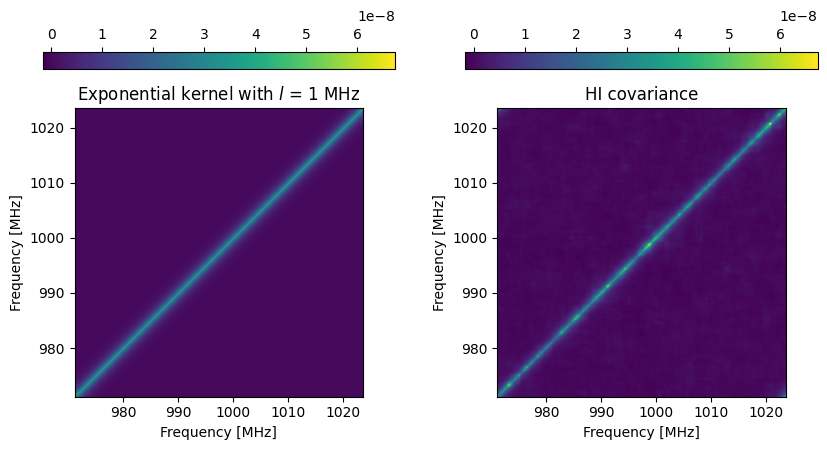

In [9]:
# plot the exponential kernal with l = 1 and the HI covariance
fig,axes = plt.subplots(1,2,figsize=(10,5))
vmin = np.min([exp_kern_hi.min(), cov_hi.min()])
vmax = np.max([exp_kern_hi.max(), cov_hi.max()])
im = axes[0].imshow(
    exp_kern_hi,origin='lower',
    extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],
    vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title(r'Exponential kernel with $l$ = 1 MHz')

im = axes[1].imshow(
    cov_hi,origin='lower',
    extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],
    vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title(r'HI covariance')


Now let us look at the foregrounds, which can be modelled by a RBF kernel:

In [10]:
# create two rbf kernals
# first with l = 10, second with l = 100
rbf_kern_1 = rbf_kernel(mock.nu/1e6,mock.nu/1e6,1,10)
rbf_kern_2 = rbf_kernel(mock.nu/1e6,mock.nu/1e6,1,100)

Text(0.5, 1.0, '$l$ = 100 MHz')

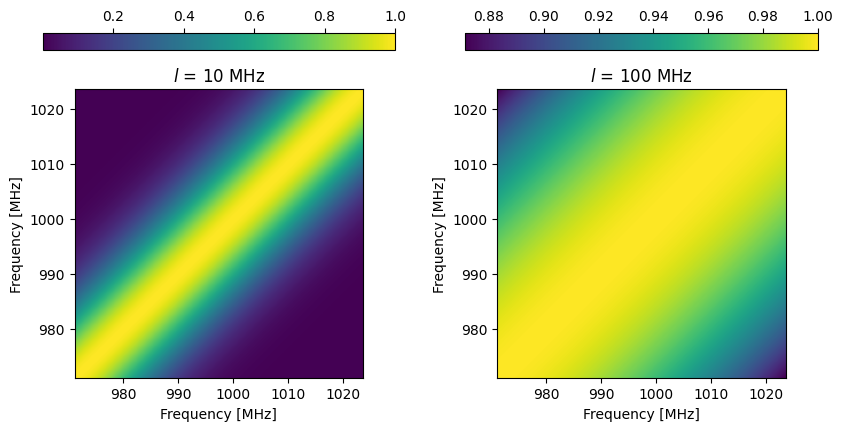

In [11]:
# plot the rbf kernals
fig,axes = plt.subplots(1,2,figsize=(10,5))
im = axes[0].imshow(rbf_kern_1,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='top',pad=0.1)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title(r'$l$ = 10 MHz')

im = axes[1].imshow(rbf_kern_2,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6])
plt.colorbar(im, location='top',pad=0.1)
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title(r'$l$ = 100 MHz')


You can see the for a RBF kernel, the kernel is much wider than the exp kernel for the same correlation length. This is ideal to describe the smooth foregrounds.

Text(0.5, 1.0, 'Foreground covariance')

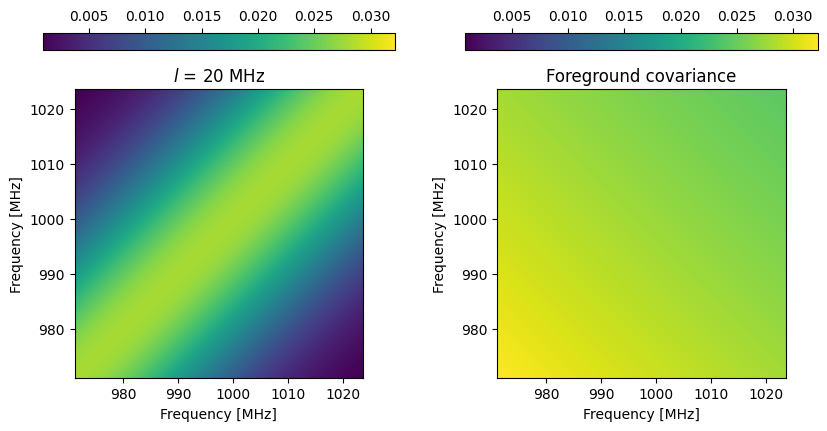

In [12]:
# plot the rbf kernal and the foreground covariance for comparison
sigma_fg_kern = np.sqrt(np.diagonal(cov_fg).mean())* 1.0
l_fg = 20
rbf_kern_fg = rbf_kernel(mock.nu/1e6,mock.nu/1e6,sigma_fg_kern,l_fg)
vmin = np.min([rbf_kern_fg.min(), cov_fg.min()])
vmax = np.max([rbf_kern_fg.max(), cov_fg.max()])
fig,axes = plt.subplots(1,2,figsize=(10,5))
im = axes[0].imshow(rbf_kern_fg,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title(r'$l$ = 20 MHz')

im = axes[1].imshow(cov_fg,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title('Foreground covariance')



However, this is still not quite matching. The problem is, the foreground has something called spectral index. That is to say, the brightness of the foreground scales according to frequency:

$$
T(f) = T_0(f_0) * (f/f_0)^\gamma
$$

This is where we want to improve from the previous work. In the RBF kernel, I allow an additional input $\gamma$:

Text(0.5, 1.0, 'Foreground covariance')

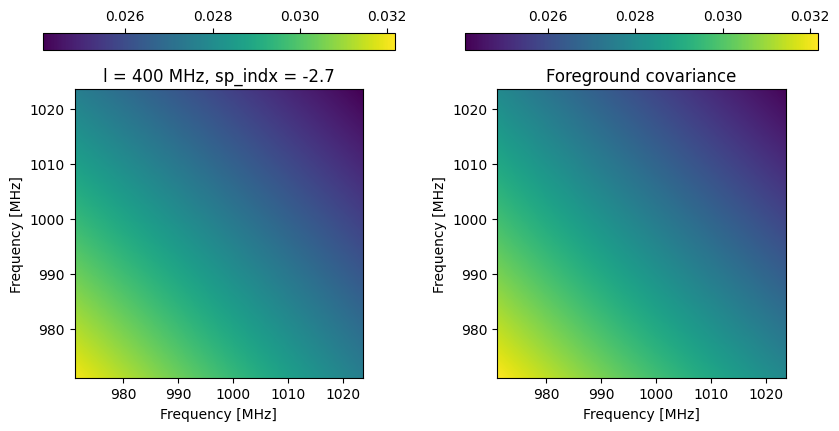

In [13]:
sigma_fg_kern = np.sqrt(np.diagonal(cov_fg).mean())* 1.07
l_fg = 400
sp_indx_fg = -2.7
rbf_kern_fg = rbf_kernel(mock.nu/1e6,mock.nu/1e6,sigma_fg_kern,l_fg,sp_indx_fg)
vmin = np.min([rbf_kern_fg.min(), cov_fg.min()])
vmax = np.max([rbf_kern_fg.max(), cov_fg.max()])
fig,axes = plt.subplots(1,2,figsize=(10,5))
im = axes[0].imshow(rbf_kern_fg,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title(f'l = {l_fg} MHz, sp_indx = {sp_indx_fg}')

im = axes[1].imshow(cov_fg,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title('Foreground covariance')



As you can see, it starts to resemble the foreground covariance.

Furthermore, we need to add in the thermal noise. There are more physical ways of generating the noise, but for now let us just add in a Gaussian noise with a standard deviation that I take from 2407.21626

In [14]:
# generate gaussian note and extract its covariance
sigma_noise = 1.21 * 1e-3
noise_map = np.random.default_rng(mock.seed).normal(0,sigma_noise,hi_map.shape) * mock.w_HI
cov_noise,_,_,_ = pca_clean(noise_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)

As we have discussed, the noise covariance should be purely diagonal:

Text(0.5, 1.0, 'Noise covariance')

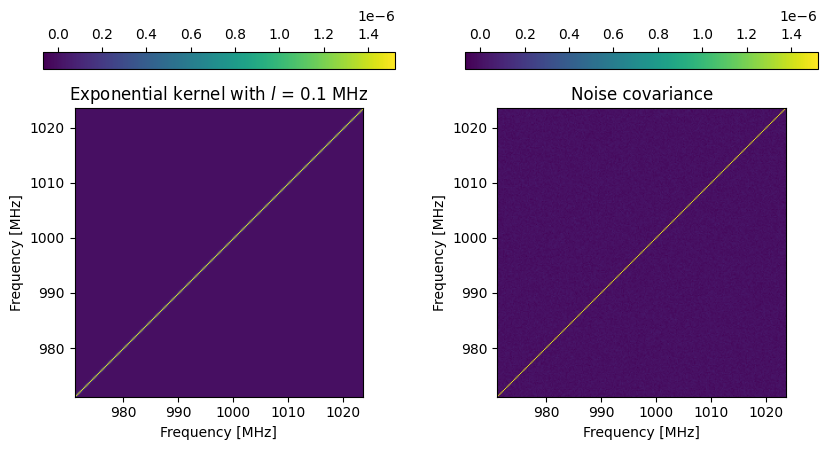

In [15]:
# plot the exponent kernal with l = 0.1 and the noise covariance
exp_kern_noise = exponential_kernel(mock.nu/1e6,mock.nu/1e6,sigma_noise,0.1)
fig,axes = plt.subplots(1,2,figsize=(10,5))
vmin = np.min([exp_kern_noise.min(), cov_noise.min()])
vmax = np.max([exp_kern_noise.max(), cov_noise.max()])
im = axes[0].imshow(
    exp_kern_noise,origin='lower',
    extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],
    vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title(r'Exponential kernel with $l$ = 0.1 MHz')

im = axes[1].imshow(
    cov_noise,origin='lower',
    extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],
    vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title(r'Noise covariance')


Note that this is just for illustration. To find the true kernel, we need to perform the optimisation routine to find the kernel parameters. See Eq 18.

In [16]:
tot_map = hi_map + fg_map + noise_map

In [17]:
cov_tot,_,_,_ = pca_clean(tot_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)

Now, let us try to find the best fit parameter for the GPR:

In [18]:
best_fit = optimize.fmin(function_to_optimise,[sigma_noise,sigma_fg_kern*1.02,l_hi,l_fg,sp_indx_fg],args=(mock.nu/1e6, cov_tot,True))

/Users/gracetait/shproject/senior_honours_project/notebooks/week5/gpr.py:28: RuntimeWarning: overflow encountered in exp
  return np.nan_to_num(sigma**2 * np.exp(-np.abs(x-y)/l))
/opt/anaconda3/envs/meer21cm/lib/python3.10/site-packages/numpy/linalg/linalg.py:2120: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/opt/anaconda3/envs/meer21cm/lib/python3.10/site-packages/numpy/linalg/linalg.py:2120: RuntimeWarning: invalid value encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/var/folders/1y/bkp6bf212cl3sq0d7bgcgtvm0000gn/T/ipykernel_7088/4092381761.py:1: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  best_fit = optimize.fmin(function_to_optimise,[sigma_noise,sigma_fg_kern*1.02,l_hi,l_fg,sp_indx_fg],args=(mock.nu/1e6, cov_tot,True))


In [19]:
fitted_pars = best_fit
fitted_hi_kern = exponential_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[0], fitted_pars[2])
fitted_fg_kern = rbf_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], fitted_pars[4])

Text(0.5, 1.0, 'Noise covariance')

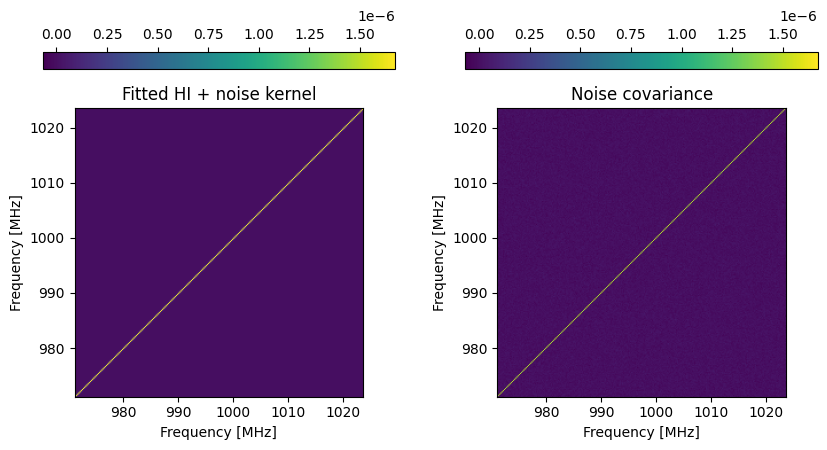

In [20]:
fig,axes = plt.subplots(1,2,figsize=(10,5))
vmin = np.min([fitted_hi_kern.min(), cov_noise.min()])
vmax = np.max([fitted_hi_kern.max(), cov_noise.max()])
im = axes[0].imshow(fitted_hi_kern,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title(r'Fitted HI + noise kernel')

im = axes[1].imshow(cov_noise,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title(r'Noise covariance')



Text(0.5, 1.0, 'Foreground covariance')

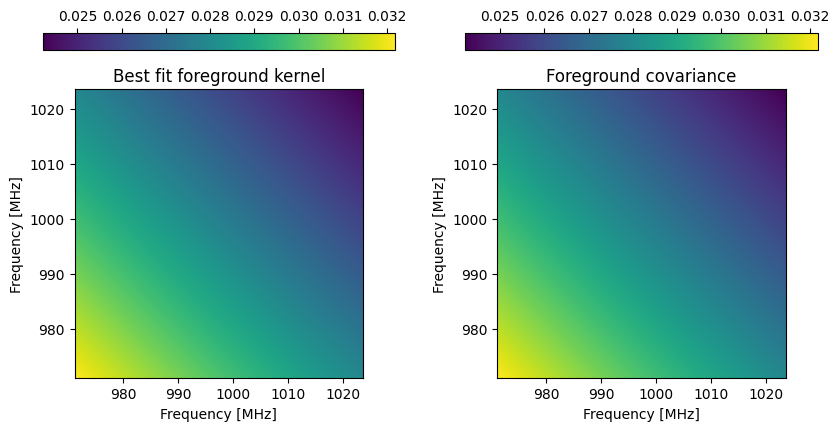

In [21]:
fig,axes = plt.subplots(1,2,figsize=(10,5))
vmin = np.min([fitted_fg_kern.min(), cov_fg.min()])
vmax = np.max([fitted_fg_kern.max(), cov_fg.max()])
im = axes[0].imshow(fitted_fg_kern,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[0].set_xlabel('Frequency [MHz]')
axes[0].set_ylabel('Frequency [MHz]')
axes[0].set_title(r'Best fit foreground kernel')

im = axes[1].imshow(cov_fg,origin='lower',extent=[mock.nu[0]/1e6,mock.nu[-1]/1e6,mock.nu[0]/1e6,mock.nu[-1]/1e6],vmin=vmin,vmax=vmax)
plt.colorbar(im, location='top',pad=0.1)
axes[1].set_xlabel('Frequency [MHz]')
axes[1].set_ylabel('Frequency [MHz]')
axes[1].set_title(r'Foreground covariance')



Now, with the fitted foreground kernel, we can remove the foreground from the data:

In [22]:
fg_remov = np.einsum(
    'ij, abj->abi',
    fitted_fg_kern @ np.linalg.inv(fitted_fg_kern + fitted_hi_kern),
    tot_map
)
res_map = tot_map - fg_remov

In [23]:
noise_residual = np.einsum(
    'ij, abj->abi',
    np.eye(mock.nu.size) - fitted_fg_kern @ np.linalg.inv(fitted_fg_kern+fitted_hi_kern),
    noise_map
)

Now let us see the removed map versus the actual map:

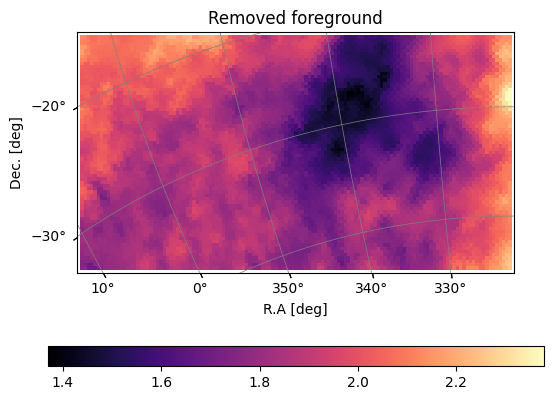

In [24]:
plot_map(fg_remov,mock.wproj,W=mock.W_HI, title='Removed foreground')

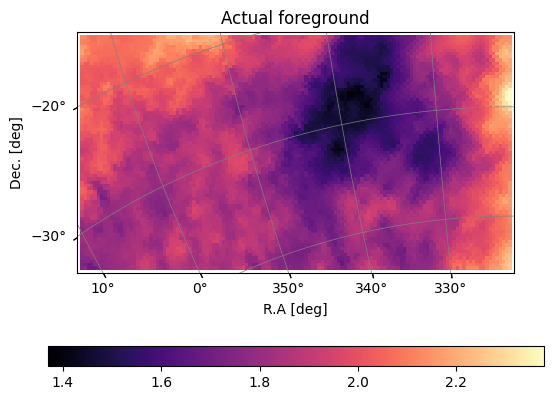

In [25]:
plot_map(fg_map,mock.wproj,W=mock.W_HI, title='Actual foreground')

As you can see the removal is quite good.

Let us check the power spectrum:

In [26]:
mock.kparabins = np.linspace(0.01, 1, 11)
mock.kperpbins = np.linspace(0.01, 0.5, 21)
mock.k1dbins = np.linspace(0, 1.2, 21)

In [27]:
mock.data = hi_map
mock.grid_data_to_field();
power_cy_hi,_ = mock.get_cy_power(mock.auto_power_3d_1)
power_1d_hi,k_1d,nmodes_1d = mock.get_1d_power(mock.auto_power_3d_1)
mock.data = res_map
mock.grid_data_to_field();
power_cy_res,_ = mock.get_cy_power(mock.auto_power_3d_1)
power_1d_res,k_1d,nmodes_1d = mock.get_1d_power(mock.auto_power_3d_1)
mock.data = noise_residual
mock.grid_data_to_field();
power_cy_noise,_ = mock.get_cy_power(mock.auto_power_3d_1)
power_1d_noise,k_1d,nmodes_1d = mock.get_1d_power(mock.auto_power_3d_1)
power_cy_res -= power_cy_noise
power_1d_res -= power_1d_noise
# Here we add in the noise, so we need to subtract out the noise power
# in real data analysis noise power can be calculated from the noise sigma

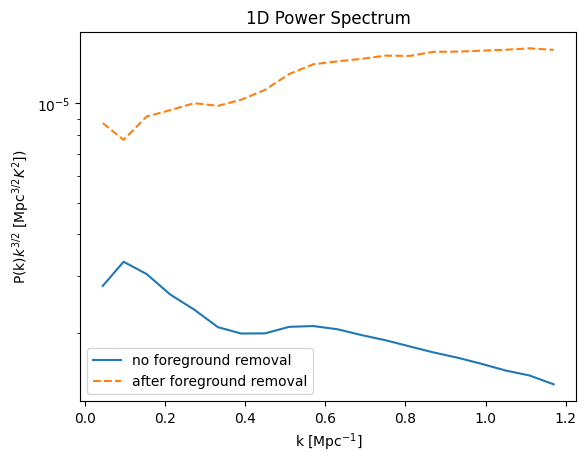

In [28]:
plt.plot(k_1d, (power_1d_hi.T)*k_1d**(3/2),label='no foreground removal')
plt.plot(k_1d, (power_1d_res.T)*k_1d**(3/2),label='after foreground removal',ls='--')
plt.xlabel('k [Mpc$^{-1}$]')
plt.ylabel(r'P(k)$k^{3/2}$ [${\rm Mpc}^{3/2}K^2]$)')
plt.yscale('log')
plt.title('1D Power Spectrum')
plt.legend()



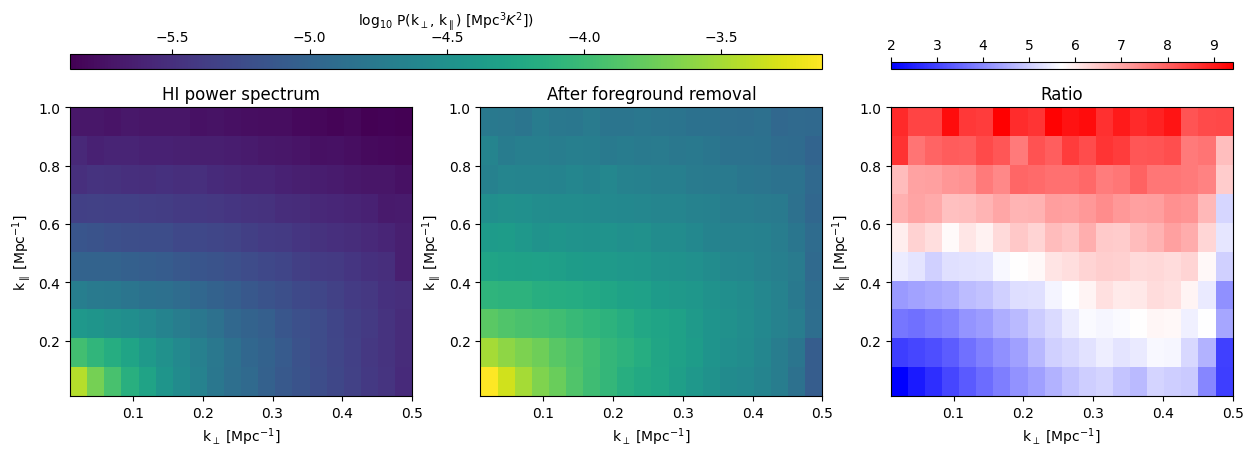

In [29]:
vmin = np.log10([power_cy_hi.min(),power_cy_res.min()]).min()
vmax = np.log10([power_cy_hi.max(),power_cy_res.max()]).max()   
fig,axes=plt.subplots(1,3,figsize=(15,5))
axes[0].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_hi.T),vmin=vmin,vmax=vmax)
axes[0].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
axes[0].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
axes[0].set_title('HI power spectrum')
im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_res.T),vmin=vmin,vmax=vmax)
axes[1].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
axes[1].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
axes[1].set_title('After foreground removal')
cbar = plt.colorbar(im,ax=axes[:2],location='top',aspect=50,pad=0.1)
cbar.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [${\rm Mpc}^{3}K^2]$)')
im = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, (power_cy_res.T/power_cy_hi.T),cmap='bwr')
axes[2].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
axes[2].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
axes[2].set_title('Ratio')
cbar = plt.colorbar(im,ax=axes[2],location='top',aspect=50,pad=0.1)
plt.show()

Things for you to try:
1. Play with the kernels and understand the kernel functions
2. Can you find a better optimisation routine to achieve a better result?

# My code

## Define functions

In [61]:
def plot_HI_signal_kernal_comparison(fitted_pars, method, save_plot = False, week_number = None):

    # generate gaussian noise and extract its covariance
    sigma_noise = 1.21 * 1e-3
    noise_map = np.random.default_rng(mock.seed).normal(0,sigma_noise,hi_map.shape) * mock.w_HI
    cov_noise,_,_,_ = pca_clean(noise_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)

    # create hi signal kernal using exponential kernal and best fit parameters
    fitted_hi_kern = exponential_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[0], fitted_pars[2])

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    im = axes[0].imshow(fitted_hi_kern, origin='lower',
                        extent=[mock.nu[0]/1e6, mock.nu[-1]/1e6, mock.nu[0]/1e6, mock.nu[-1]/1e6])
    plt.colorbar(im, location='top', pad=0.1)
    axes[0].set_xlabel('Frequency [MHz]')
    axes[0].set_ylabel('Frequency [MHz]')
    axes[0].set_title(r'Fitted HI + noise kernel')
    
    im = axes[1].imshow(cov_noise, origin='lower',
                        extent=[mock.nu[0]/1e6, mock.nu[-1]/1e6, mock.nu[0]/1e6, mock.nu[-1]/1e6])
    plt.colorbar(im, location='top', pad=0.1)
    axes[1].set_xlabel('Frequency [MHz]')
    axes[1].set_ylabel('Frequency [MHz]')
    axes[1].set_title(r'Noise covariance')

    # save plot
    if save_plot == True:
        save_project_plot(plt.gcf(), week_number = week_number, 
                          filename = f"hi_signal_kernal_comparison_{method}.pdf")
    
    plt.tight_layout()
    plt.show()

In [62]:
def plot_foreground_signal_kernal_comparison(fitted_pars, method, save_plot = False, week_number = None):
    
    # create the foreground kernal using the rbf kernal and best fit parameters
    fitted_fg_kern = rbf_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1], fitted_pars[3], fitted_pars[4])
    
    # plot the best fitted kernal and foreground covariance with independent colour scales
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    im = axes[0].imshow(fitted_fg_kern, origin='lower', extent=[mock.nu[0]/1e6, mock.nu[-1]/1e6, mock.nu[0]/1e6, mock.nu[-1]/1e6])
    plt.colorbar(im, location='top', pad=0.1)
    axes[0].set_xlabel('Frequency [MHz]')
    axes[0].set_ylabel('Frequency [MHz]')
    axes[0].set_title(r'Best fit foreground kernel')
    
    im = axes[1].imshow(cov_fg, origin='lower', extent=[mock.nu[0]/1e6, mock.nu[-1]/1e6, mock.nu[0]/1e6, mock.nu[-1]/1e6])
    plt.colorbar(im, location='top', pad=0.1)
    axes[1].set_xlabel('Frequency [MHz]')
    axes[1].set_ylabel('Frequency [MHz]')
    axes[1].set_title(r'Foreground covariance')

    # save plot
    if save_plot == True:
        save_project_plot(plt.gcf(), week_number = week_number, 
                          filename = f"fg_signal_kernal_comparison_{method}.pdf")
    
    plt.tight_layout()
    plt.show()

In [63]:
def foreground_kernal_removal_plots(fitted_pars, method, save_plot = False, week_number = None):

    fitted_hi_kern = exponential_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[0], fitted_pars[2])
    fitted_fg_kern = rbf_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], fitted_pars[4])

    fg_remov = np.einsum(
    'ij, abj->abi',
    fitted_fg_kern @ np.linalg.inv(fitted_fg_kern + fitted_hi_kern),
    tot_map
    )
    res_map = tot_map - fg_remov

    noise_residual = np.einsum(
    'ij, abj->abi',
    np.eye(mock.nu.size) - fitted_fg_kern @ np.linalg.inv(fitted_fg_kern+fitted_hi_kern),
    noise_map
    )

    plot_map(fg_remov,mock.wproj,W=mock.W_HI, title='Removed foreground')

    # save plot
    if save_plot == True:
        save_project_plot(plt.gcf(), week_number = week_number, 
                          filename = f"removed_kernal_foreground_{method}.pdf")

    plot_map(fg_map,mock.wproj,W=mock.W_HI, title='Actual foreground')

    # save plot
    if save_plot == True:
        save_project_plot(plt.gcf(), week_number = week_number, 
                          filename = f"removed_actual_foreground_{method}.pdf")

In [163]:
def kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method, save_plot = False, week_number = None):

    fitted_hi_kern = exponential_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[0], fitted_pars[2])
    fitted_fg_kern = rbf_kernel(mock.nu / 1e6, mock.nu / 1e6, fitted_pars[1] , fitted_pars[3], fitted_pars[4])

    fg_remov = np.einsum(
    'ij, abj->abi',
    fitted_fg_kern @ np.linalg.inv(fitted_fg_kern + fitted_hi_kern),
    tot_map
    )
    res_map = tot_map - fg_remov

    noise_residual = np.einsum(
    'ij, abj->abi',
    np.eye(mock.nu.size) - fitted_fg_kern @ np.linalg.inv(fitted_fg_kern+fitted_hi_kern),
    noise_map
    )

    mock.kparabins = np.linspace(0.01, 1, 11)
    mock.kperpbins = np.linspace(0.01, 0.5, 21)
    mock.k1dbins = np.linspace(0, 1.2, 21)

    mock.data = hi_map
    mock.grid_data_to_field();
    power_cy_hi,_ = mock.get_cy_power(mock.auto_power_3d_1)
    power_1d_hi,k_1d,nmodes_1d = mock.get_1d_power(mock.auto_power_3d_1)
    mock.data = res_map
    mock.grid_data_to_field();
    power_cy_res,_ = mock.get_cy_power(mock.auto_power_3d_1)
    power_1d_res,k_1d,nmodes_1d = mock.get_1d_power(mock.auto_power_3d_1)
    mock.data = noise_residual
    mock.grid_data_to_field();
    power_cy_noise,_ = mock.get_cy_power(mock.auto_power_3d_1)
    power_1d_noise,k_1d,nmodes_1d = mock.get_1d_power(mock.auto_power_3d_1)
    power_cy_res -= power_cy_noise
    power_1d_res -= power_1d_noise
    # Here we add in the noise, so we need to subtract out the noise power
    # in real data analysis noise power can be calculated from the noise sigma

    # 1D power spectrum
    plt.plot(k_1d, (power_1d_hi.T)*k_1d**(3/2),label='no foreground removal', color = 'blue')
    plt.plot(k_1d, (power_1d_res.T)*k_1d**(3/2),label='after foreground removal',ls='--', color = 'red')
    plt.xlabel('k [Mpc$^{-1}$]')
    plt.ylabel(r'P(k)$k^{3/2}$ [${\rm Mpc}^{3/2}K^2]$)')
    plt.title('1D Power Spectrum')
    plt.legend()
    if save_plot:
        save_project_plot(plt.gcf(), week_number=week_number,
                          filename=f"1d_power_spectrum_{method}.pdf")
    plt.show()
    
    # 1D power spectrum residuals
    y_hi = (power_1d_hi.T) * k_1d**(3/2)
    y_res = (power_1d_res.T) * k_1d**(3/2)
    residual = y_res - y_hi  # difference between cleaned and true HI
    plt.plot(k_1d, residual, color='red', ls='--', label='residual (after - before)')
    plt.axhline(0, color='blue', linewidth=0.8)  # zero line for reference
    plt.xlabel('k [Mpc$^{-1}$]')
    plt.ylabel(r'$\Delta$P(k)$k^{3/2}$ [Mpc$^{3/2}$K$^2$]')
    plt.title('Residual')
    plt.legend()
    if save_plot:
        save_project_plot(plt.gcf(), week_number=week_number,
                          filename=f"1d_power_spectrum_residuals_{method}.pdf")
    plt.show()

    # 1D power spectrum
    log_power_1d_hi = np.log10(power_1d_hi)
    log_power_1d_res = np.log10(power_1d_res)
    plt.plot(k_1d, log_power_1d_hi, label='no foreground removal', color = 'blue', linewidth = 1)
    plt.plot(k_1d, log_power_1d_res, label='after foreground removal',ls='--', color = 'red', linewidth = 1)
    plt.xlabel('k [Mpc$^{-1}$]')
    plt.ylabel(r'log$_{10}$ P(k) [${\rm Mpc}^{3}K^2]$)')
    plt.title('1D Power Spectrum')
    plt.legend()
    # save plot
    if save_plot == True:
        save_project_plot(plt.gcf(), week_number = week_number, 
                          filename = f"log_1d_power_spectrum_{method}.pdf") 
    plt.show()
    
    # log 1D power spectrum residuals
    y_hi = log_power_1d_hi
    y_res = log_power_1d_res
    residual = y_res - y_hi  # difference between cleaned and true HI
    plt.plot(k_1d, residual, color='red', ls='--', label='residual (after - before)')
    plt.axhline(0, color='blue', linewidth=0.8)  # zero line for reference
    plt.xlabel('k [Mpc$^{-1}$]')
    plt.ylabel(r'$\Delta$P(k)$k^{3/2}$ [Mpc$^{3/2}$K$^2$]')
    plt.title('Residual')
    plt.legend()
    # save plot
    if save_plot == True:
        save_project_plot(plt.gcf(), week_number = week_number, 
                          filename = f"log_1d_power_spectrum_residuals_{method}.pdf")
    plt.show()

    # cylindrical power spectrum
    vmin = np.log10([power_cy_hi.min(),power_cy_res.min()]).min()
    vmax = np.log10([power_cy_hi.max(),power_cy_res.max()]).max()   
    fig,axes=plt.subplots(1,3,figsize=(15,5))
    axes[0].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_hi.T),vmin=vmin,vmax=vmax)
    axes[0].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
    axes[0].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
    axes[0].set_title('HI power spectrum')
    im = axes[1].pcolormesh(mock.kperpbins, mock.kparabins, np.log10(power_cy_res.T),vmin=vmin,vmax=vmax)
    axes[1].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
    axes[1].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
    axes[1].set_title('After foreground removal')
    cbar = plt.colorbar(im,ax=axes[:2],location='top',aspect=50,pad=0.1)
    cbar.set_label(r'log$_{10}$ P(k$_\perp$, k$_\parallel$) [${\rm Mpc}^{3}K^2]$)')
    im = axes[2].pcolormesh(mock.kperpbins, mock.kparabins, (power_cy_res.T/power_cy_hi.T),cmap='bwr')
    axes[2].set_xlabel('k$_\perp$ [Mpc$^{-1}$]')
    axes[2].set_ylabel('k$_\parallel$ [Mpc$^{-1}$]')
    axes[2].set_title('Ratio')
    cbar = plt.colorbar(im,ax=axes[2],location='top',aspect=50,pad=0.1)

    # save plot
    if save_plot == True:
        save_project_plot(plt.gcf(), week_number = week_number, 
                          filename = f"cylindrical_power_spectrum_{method}.pdf")
        
    plt.show()

In [8]:
# copy and paste in function which makes saving files easier
def save_project_plot(fig, week_number, filename):
    """
    Saves a matplotlib figure to a specific week's folder.
    Example: week_number=1 saves to .../outputs/week1/
    """
    # 1. Define the base path
    base_path = "/Users/gracetait/shproject/senior_honours_project/outputs"
    
    # 2. Create the week-specific folder name
    week_folder = f"week{week_number}"
    
    # 3. Combine them into a full path
    target_dir = os.path.join(base_path, week_folder)
    
    # 4. Create the directory if it doesn't exist yet
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)
        print(f"Created new directory: {target_dir}")
    
    # 5. Define the final file path
    save_path = os.path.join(target_dir, filename)
    
    # 6. Save the figure
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Successfully saved: {save_path}")

In [165]:
# generate a list of 100 integers [1, 2, 3, ..., 100]
seeds = np.arange(1, 101)

## Without any optimisations and just initial guesses

In [166]:
fitted_pars = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
print(fitted_pars)

[ 1.90448375e-04  1.82551820e-01  1.00000000e+00  4.00000000e+02
 -2.70000000e+00]


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/hi_signal_kernal_comparison_no_optimisation.pdf


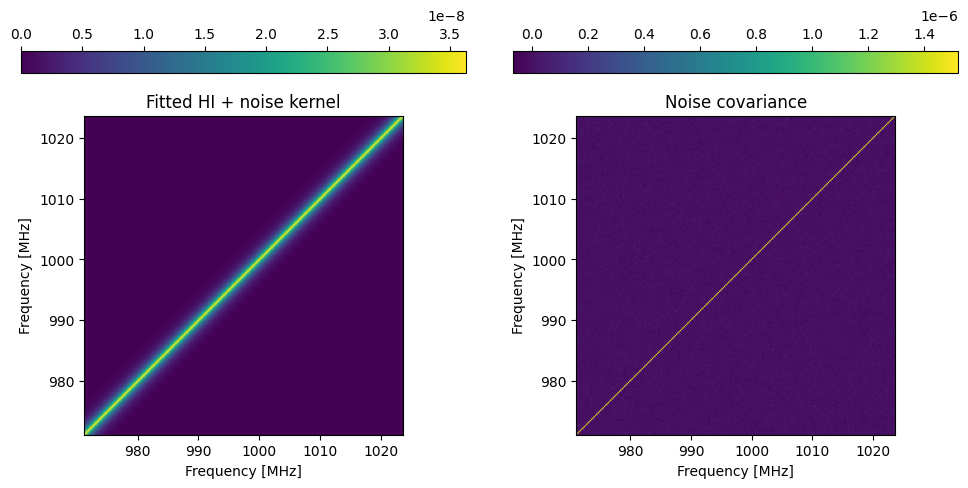

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/fg_signal_kernal_comparison_no_optimisation.pdf


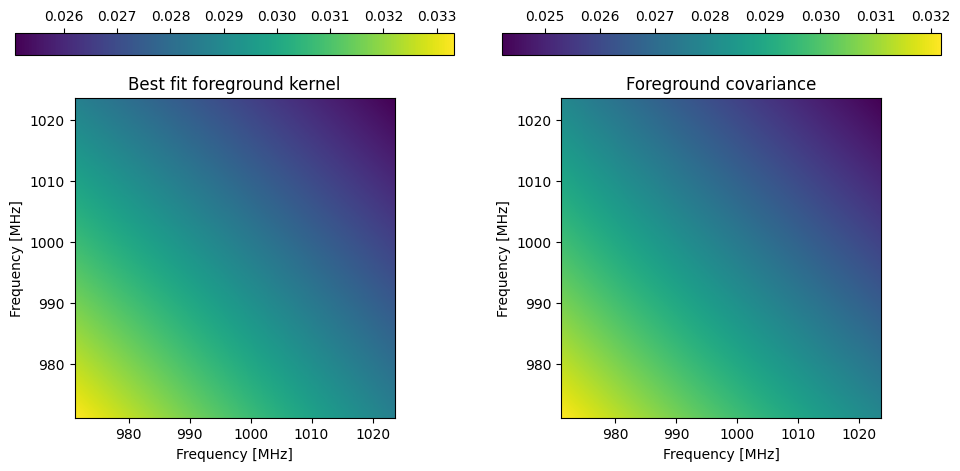

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/removed_kernal_foreground_no_optimisation.pdf
Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/removed_actual_foreground_no_optimisation.pdf


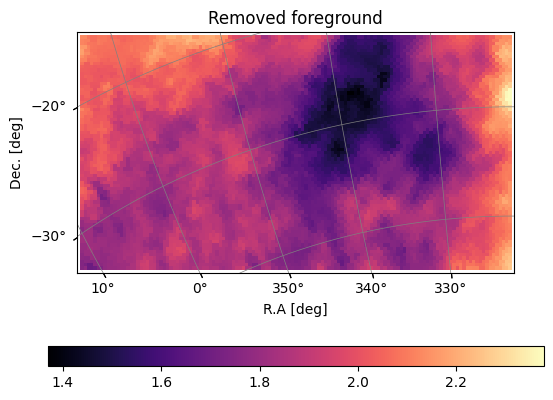

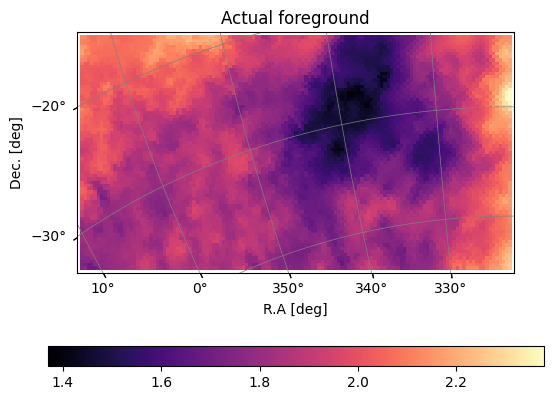

In [167]:
plot_HI_signal_kernal_comparison(fitted_pars, method = "no_optimisation", save_plot = True, week_number = 5)
plot_foreground_signal_kernal_comparison(fitted_pars, method = "no_optimisation", save_plot = True, week_number = 5)
foreground_kernal_removal_plots(fitted_pars, method = "no_optimisation", save_plot = True, week_number = 5)

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/1d_power_spectrum_no_optimisation.pdf


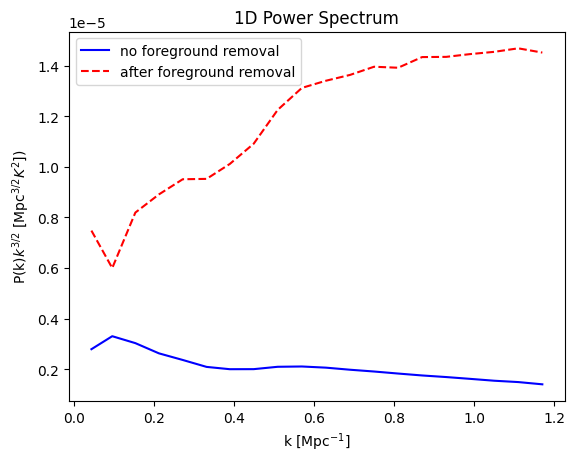

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/1d_power_spectrum_residuals_no_optimisation.pdf


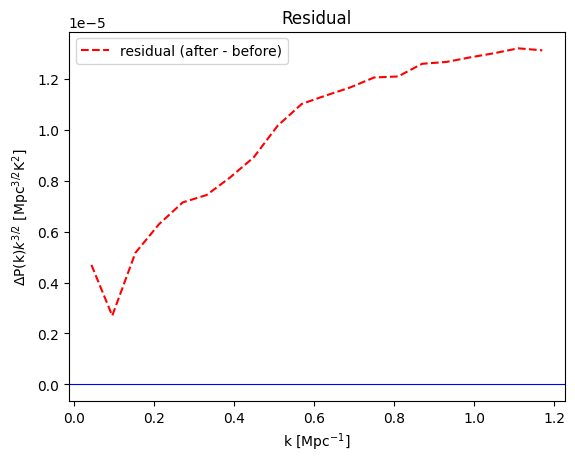

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/log_1d_power_spectrum_no_optimisation.pdf


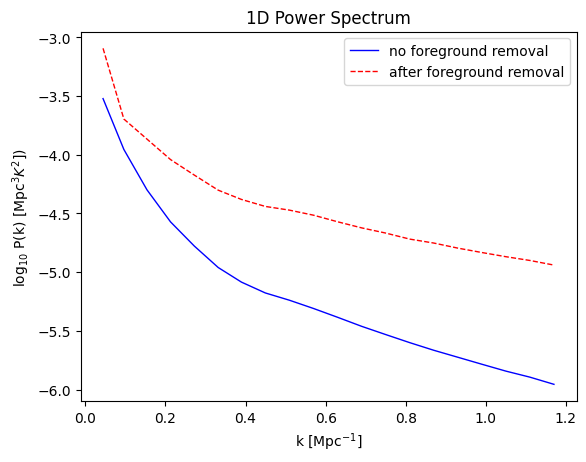

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/log_1d_power_spectrum_residuals_no_optimisation.pdf


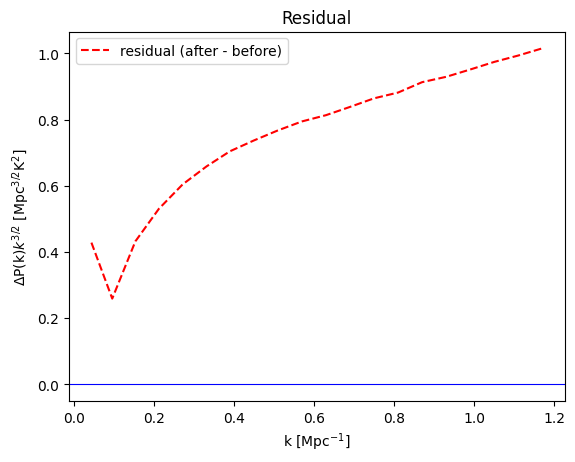

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/cylindrical_power_spectrum_no_optimisation.pdf


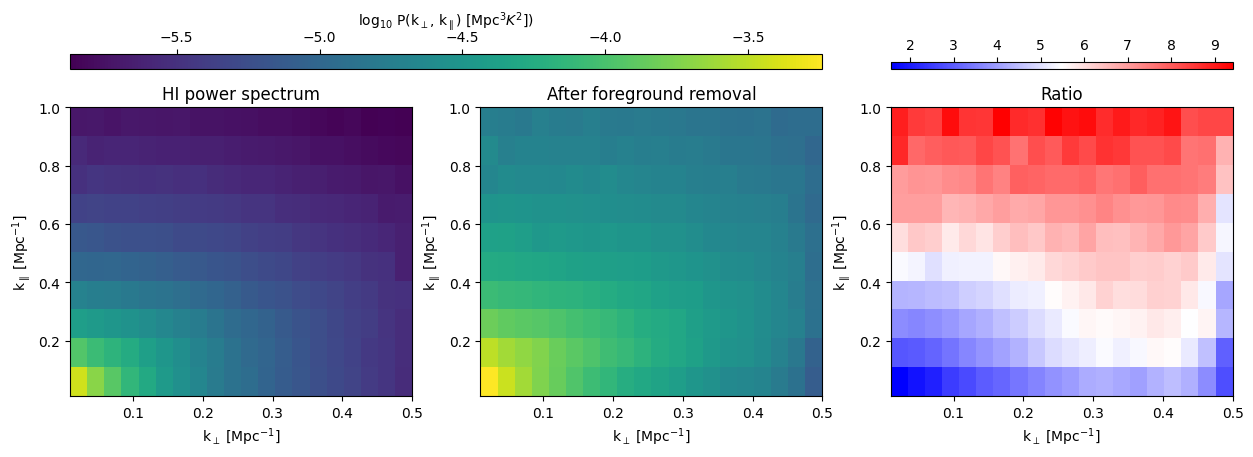

In [168]:
kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "no_optimisation", save_plot = True, week_number = 5)

## Scipy optimise minimise with no bounds

In [169]:
### best fit parameters extracted
#### 0 = sigma_hi = amplitude of the HI signal
#### 1 = sigma_fg = amplitude of the foregrounds
#### 2 = l_hi = correlation length of the HI signal
#### 3 = l_fg = correlation length of the foreground
#### 4 = sp_indx = spectral index scaling

In [170]:
# lets try a different scipy optimise function = minimize
tot_map = hi_map + fg_map + noise_map
cov_tot,_,_,_ = pca_clean(tot_map,1,weights=mock.w_HI,return_analysis=True,mean_center=True)
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
args = (mock.nu / 1e6, cov_tot)
best_fit = optimize.minimize(fun = function_to_optimise, x0 = x0, args = args) #  method = 'Nelder-Mead'

In [171]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x

Optimization Success: False
Reason for stopping: Desired error not necessarily achieved due to precision loss.
Optimized Parameters: [ 6.46189880e-01  9.95758250e-02  3.37992597e+03  4.00367278e+02
 -3.69321618e+01]
Log-Marginial Likeligood: -1231.4628349035102


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/hi_signal_kernal_comparison_default_no_bounds.pdf


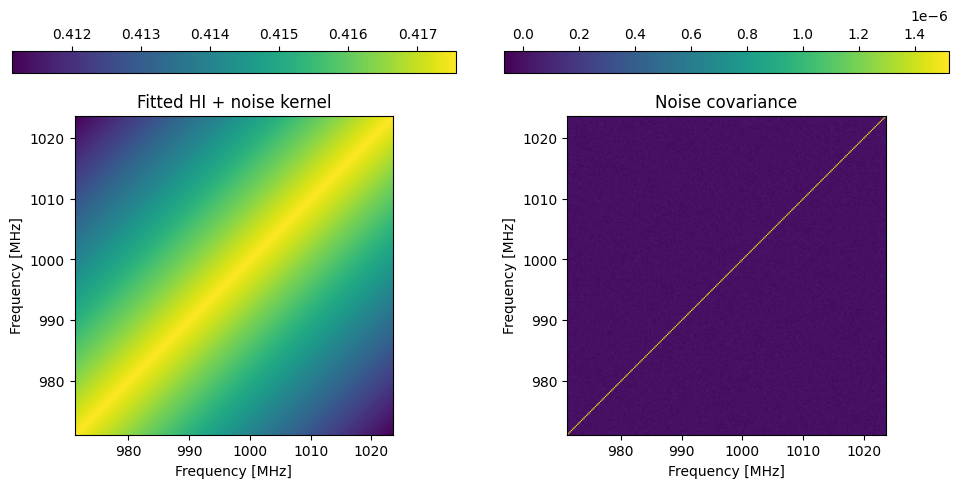

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/fg_signal_kernal_comparison_default_no_bounds.pdf


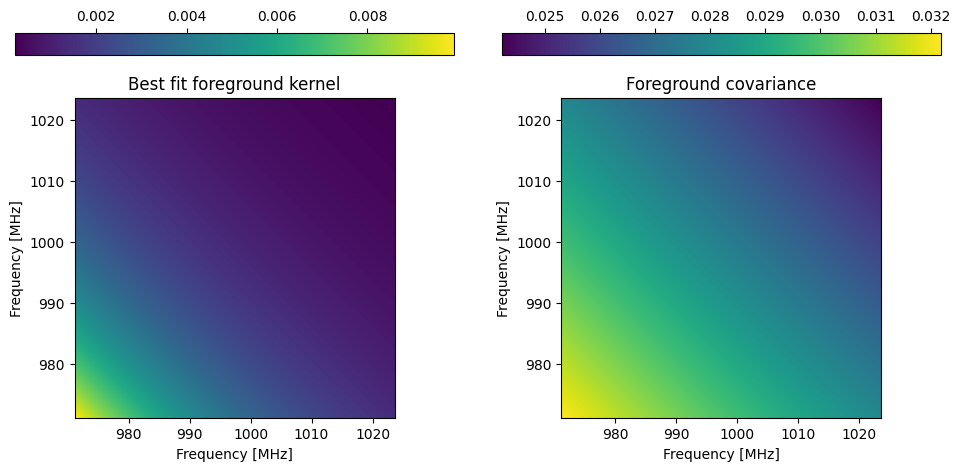

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/removed_kernal_foreground_default_no_bounds.pdf
Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/removed_actual_foreground_default_no_bounds.pdf


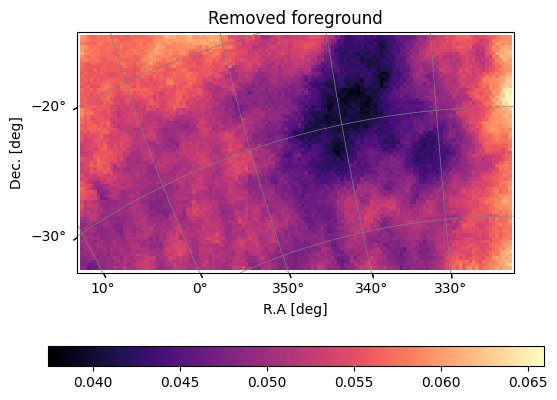

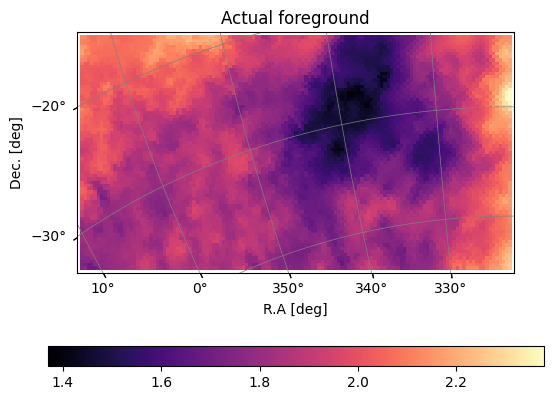

In [172]:
plot_HI_signal_kernal_comparison(fitted_pars, method = "default_no_bounds", save_plot = True, week_number = 5)
plot_foreground_signal_kernal_comparison(fitted_pars, method = "default_no_bounds", save_plot = True, week_number = 5)
foreground_kernal_removal_plots(fitted_pars, method = "default_no_bounds", save_plot = True, week_number = 5)

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/1d_power_spectrum_default_no_bounds.pdf


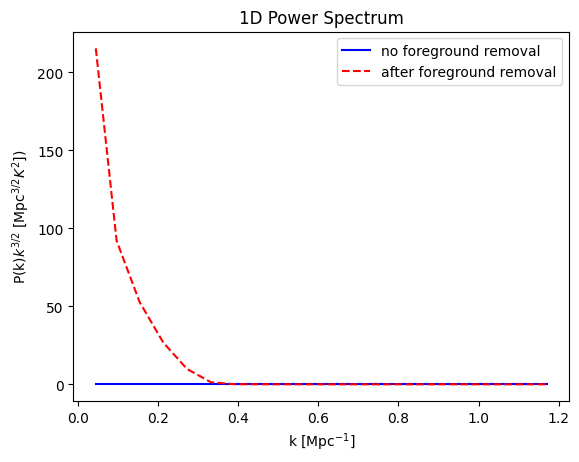

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/1d_power_spectrum_residuals_default_no_bounds.pdf


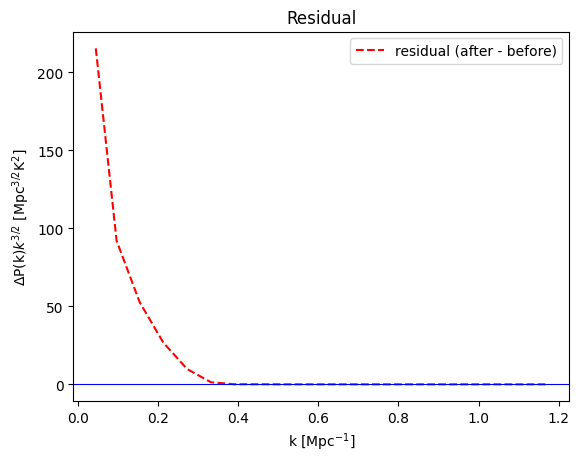

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/log_1d_power_spectrum_default_no_bounds.pdf


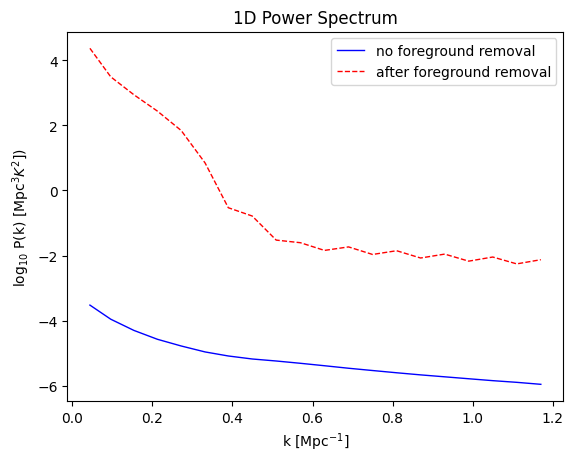

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/log_1d_power_spectrum_residuals_default_no_bounds.pdf


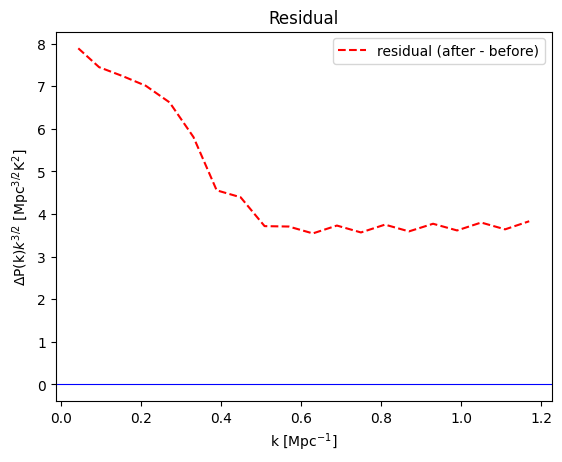

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/cylindrical_power_spectrum_default_no_bounds.pdf


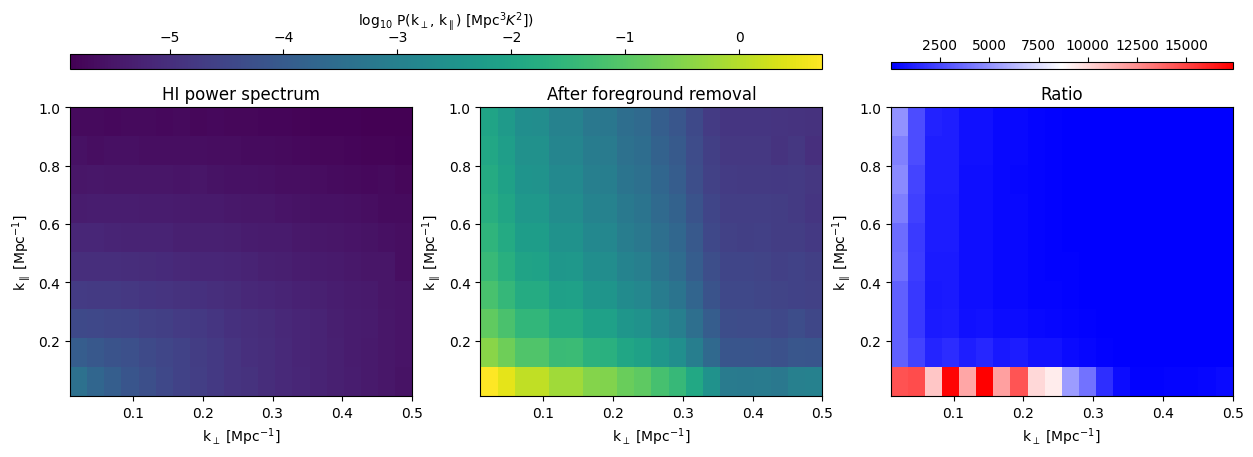

In [173]:
kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "default_no_bounds", save_plot = True, week_number = 5)

## Scipy optimise minimise with bounds

In [174]:
# lets try a different scipy optimise function = minimize
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
args = (mock.nu / 1e6, cov_tot)
bounds = bounds = [
    (1e-6, None),   # Amplitudes must be positive
    (1e-6, None), 
    (0.01, 2.0),  # hi length scale (MHz)
    (10.0, 100.0),  # foreground length scale (MHz)
    (None, None)    # spectral index can be anything
]
best_fit = optimize.minimize(fun = function_to_optimise, x0 = x0, args = args, bounds = bounds) #  method = 'Nelder-Mead'

In [175]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x

Optimization Success: True
Reason for stopping: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Optimized Parameters: [ 1.29113831e-03  1.19822213e-01  8.04152082e-02  1.00000000e+02
 -2.69771211e+00]
Log-Marginial Likeligood: -1535.211712474304


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/hi_signal_kernal_comparison_default_with_bounds1.pdf


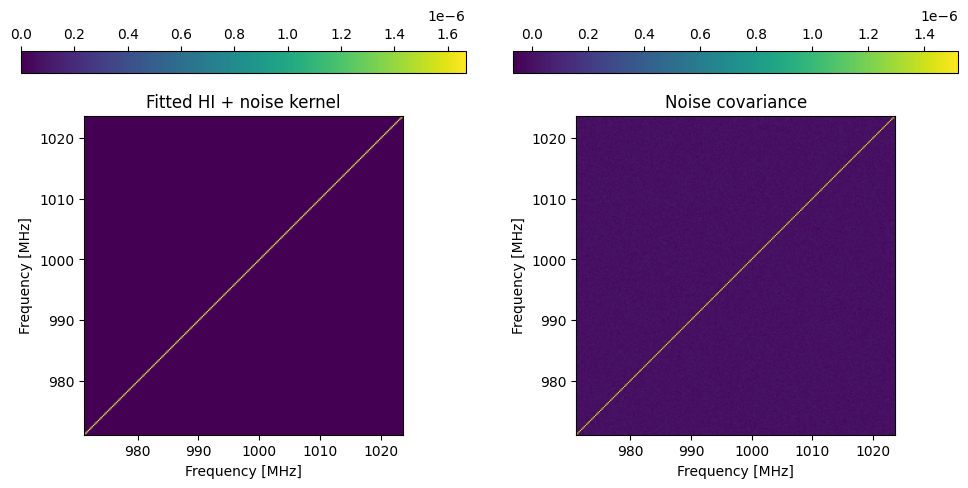

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/fg_signal_kernal_comparison_default_with_bounds1.pdf


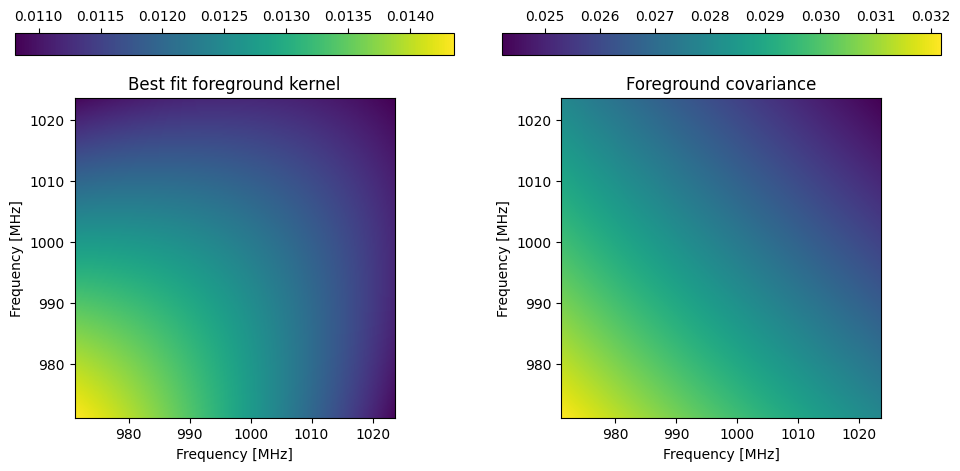

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/removed_kernal_foreground_default_with_bounds1.pdf
Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/removed_actual_foreground_default_with_bounds1.pdf


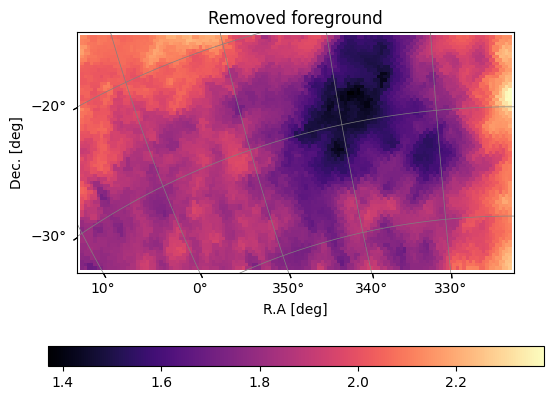

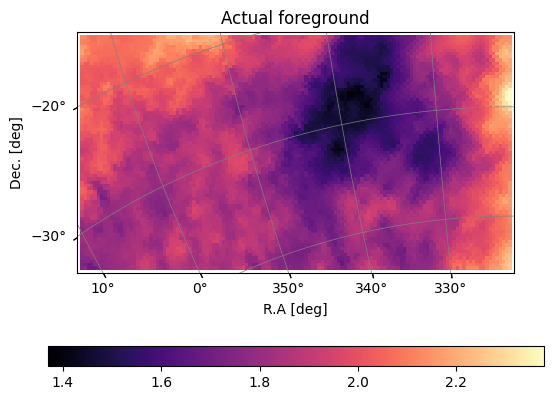

In [176]:
plot_HI_signal_kernal_comparison(fitted_pars, method = "default_with_bounds1", save_plot = True, week_number = 5)
plot_foreground_signal_kernal_comparison(fitted_pars, method = "default_with_bounds1", save_plot = True, week_number = 5)
foreground_kernal_removal_plots(fitted_pars, method = "default_with_bounds1", save_plot = True, week_number = 5)

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/1d_power_spectrum_default_with_bounds1.pdf


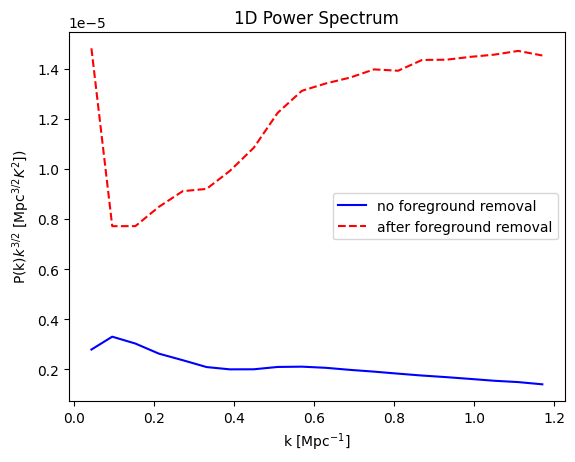

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/1d_power_spectrum_residuals_default_with_bounds1.pdf


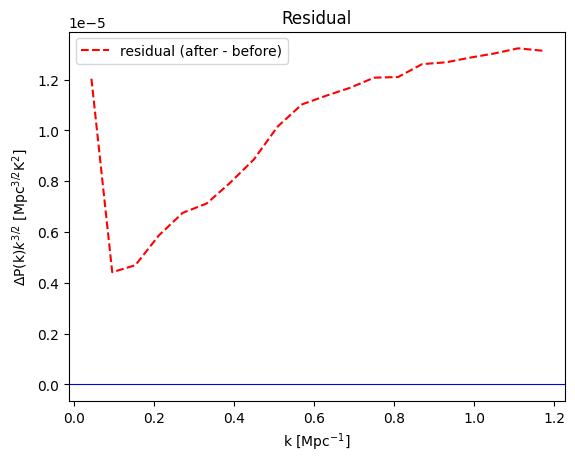

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/log_1d_power_spectrum_default_with_bounds1.pdf


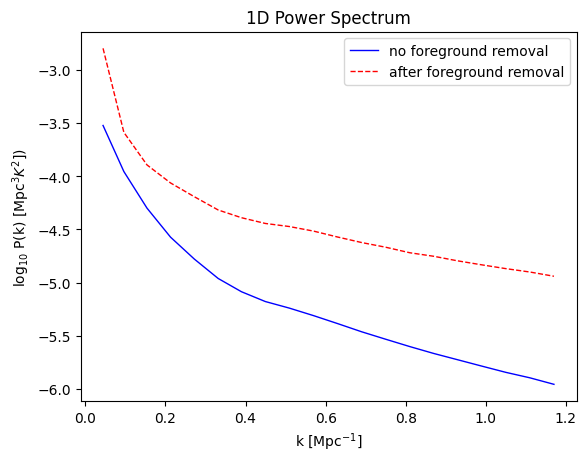

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/log_1d_power_spectrum_residuals_default_with_bounds1.pdf


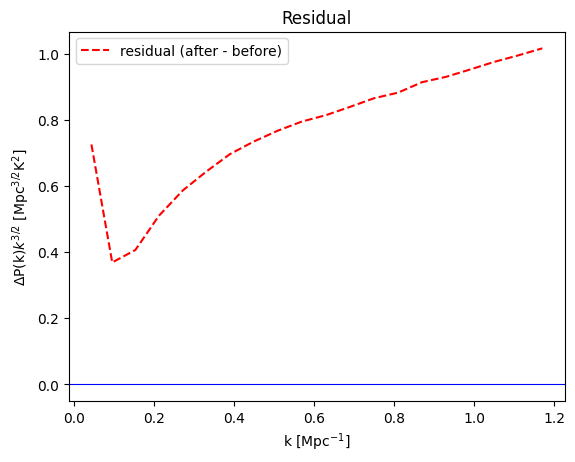

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/cylindrical_power_spectrum_default_with_bounds1.pdf


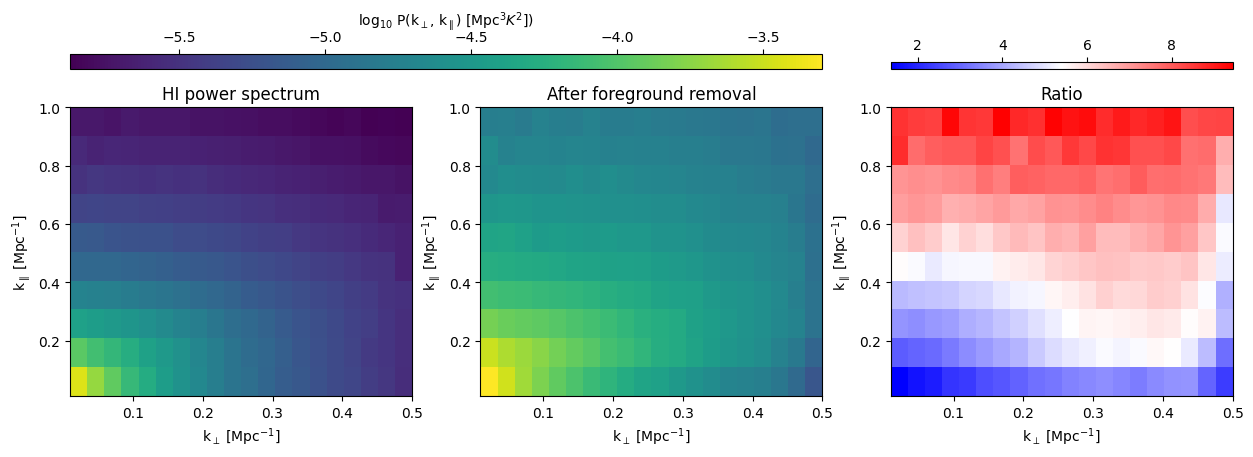

In [177]:
kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "default_with_bounds1", save_plot = True, week_number = 5)

In [178]:
# lets try a different scipy optimise function = minimize
x0 = np.array([sigma_hi_kern, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
args = (mock.nu / 1e6, cov_tot)
bounds = [
    (1e-6, None),     # sigma_hi
    (1e-6, None),     # sigma_fg
    (1e-4, 5.0),       # l_hi: keep physically reasonable, not vanishingly small
    (10.0, 10000.0),  # l_fg
    (-5.0, -0.1),     # sp_indx_fg: physically must be negative
]
best_fit = optimize.minimize(fun = function_to_optimise, x0 = x0, args = args, bounds = bounds) #  method = 'Nelder-Mead'

In [179]:
print(x0)
print(best_fit.x)

[ 1.90448375e-04  1.82551820e-01  1.00000000e+00  4.00000000e+02
 -2.70000000e+00]
[ 1.29252342e-03  1.29486847e-01  8.12446181e-02  4.00000403e+02
 -2.70128396e+00]


In [180]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x

Optimization Success: True
Reason for stopping: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
Optimized Parameters: [ 1.29252342e-03  1.29486847e-01  8.12446181e-02  4.00000403e+02
 -2.70128396e+00]
Log-Marginial Likeligood: -1539.1740733998759


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/hi_signal_kernal_comparison_default_with_bounds2.pdf


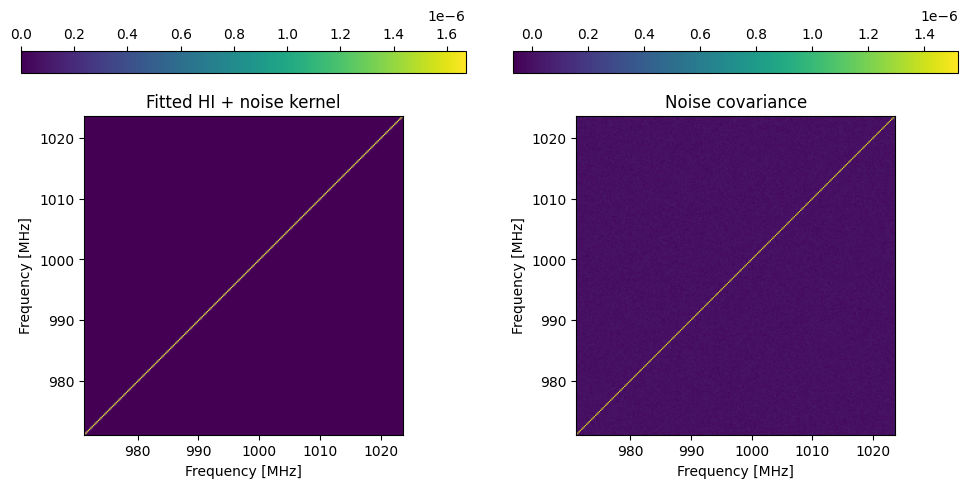

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/fg_signal_kernal_comparison_default_with_bounds2.pdf


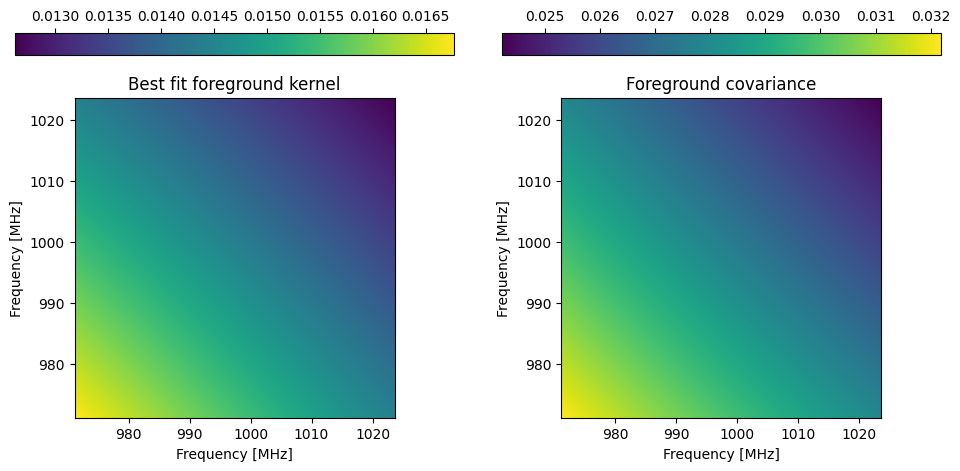

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/removed_kernal_foreground_default_with_bounds2.pdf
Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/removed_actual_foreground_default_with_bounds2.pdf


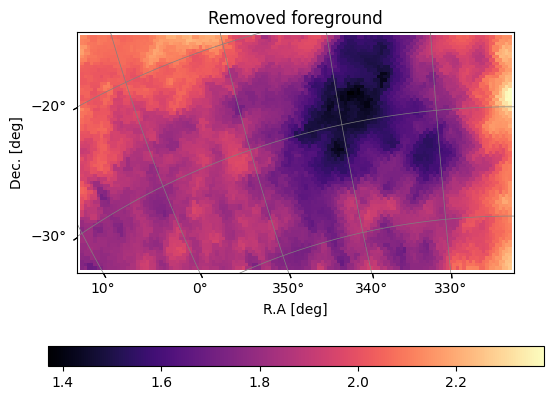

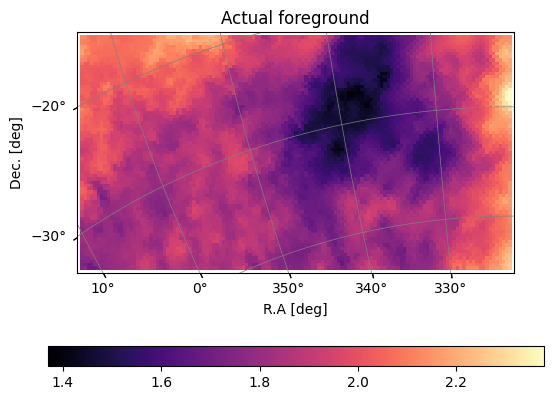

In [181]:
plot_HI_signal_kernal_comparison(fitted_pars, method = "default_with_bounds2", save_plot = True, week_number = 5)
plot_foreground_signal_kernal_comparison(fitted_pars, method = "default_with_bounds2", save_plot = True, week_number = 5)
foreground_kernal_removal_plots(fitted_pars, method = "default_with_bounds2", save_plot = True, week_number = 5)

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/1d_power_spectrum_default_with_bounds2.pdf


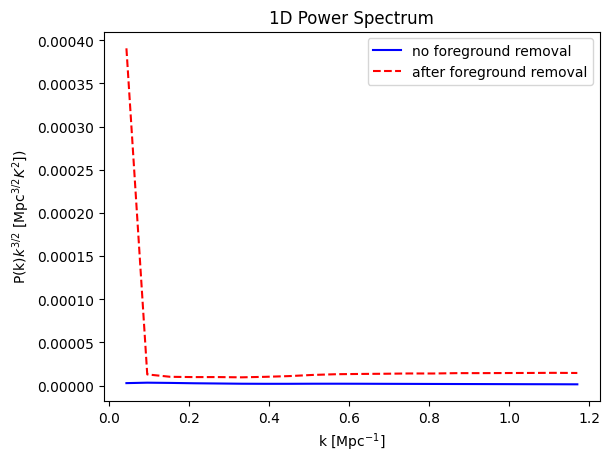

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/1d_power_spectrum_residuals_default_with_bounds2.pdf


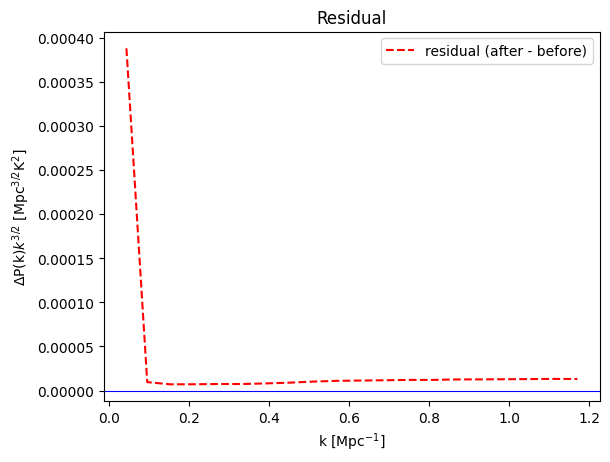

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/log_1d_power_spectrum_default_with_bounds2.pdf


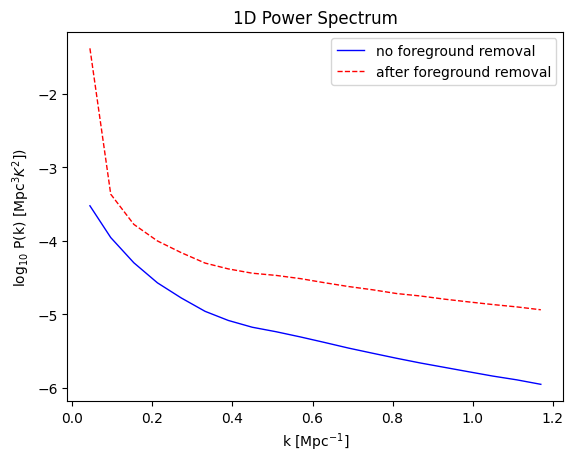

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/log_1d_power_spectrum_residuals_default_with_bounds2.pdf


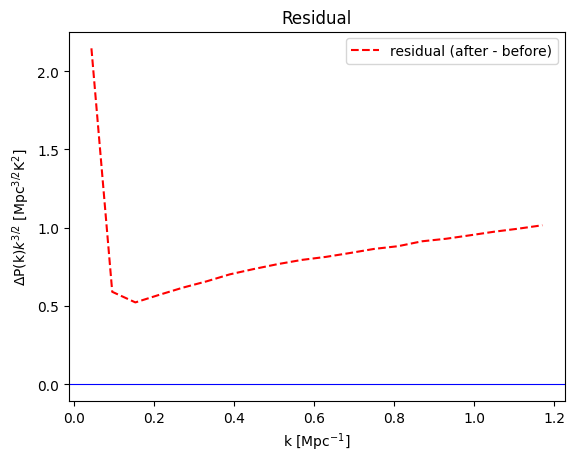

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/cylindrical_power_spectrum_default_with_bounds2.pdf


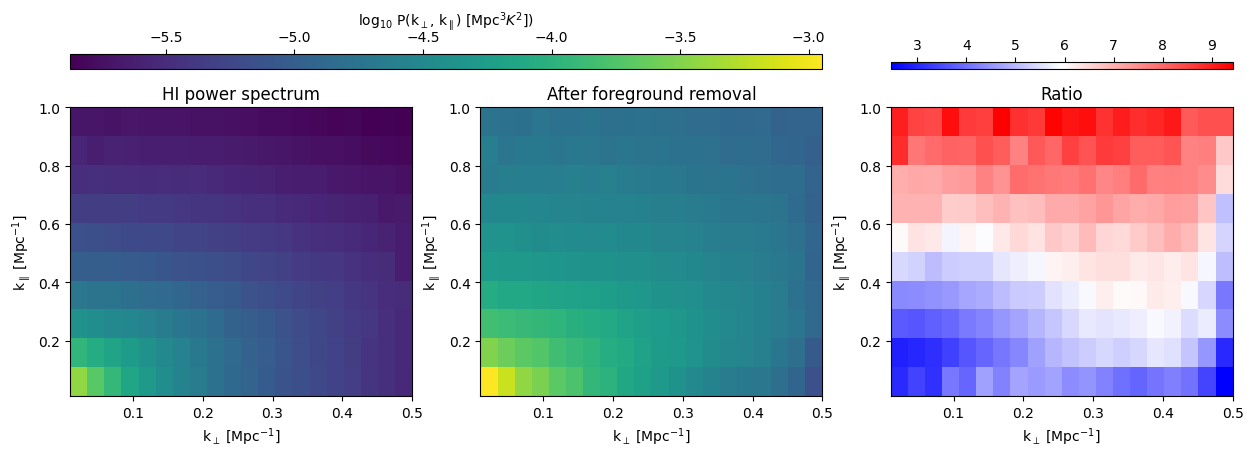

In [182]:
kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "default_with_bounds2", save_plot = True, week_number = 5)

## Nelder-Mead method

In [183]:
# lets try optimize.fmin again
# lets try a different scipy optimise function = minimize
x0 = np.array([sigma_noise, sigma_fg_kern * 1.02, l_hi, l_fg, sp_indx_fg], dtype = float)
args = (mock.nu / 1e6, cov_tot)
bounds = bounds = [
    (1e-6, None),   # Amplitudes must be positive
    (1e-6, None), 
    (0.01, 2.0),  # hi length scale (MHz)
    (10.0, 10000.0),  # foreground length scale (MHz)
    (None, None)    # spectral index can be anything
]
best_fit = optimize.minimize(fun = function_to_optimise, x0 = x0, args = args, bounds = bounds, method = 'Nelder-Mead',
    options={'maxiter': 2000, 'maxfev': 5000})

In [184]:
print(f"Optimization Success: {best_fit.success}")
print(f"Reason for stopping: {best_fit.message}")
print(f"Optimized Parameters: {best_fit.x}")
print(f"Log-Marginial Likeligood: {best_fit.fun}")
fitted_pars = best_fit.x
#print(best_fit)

Optimization Success: True
Reason for stopping: Optimization terminated successfully.
Optimized Parameters: [ 1.29296239e-03  1.38955934e-01  8.14867198e-02  9.99999920e+03
 -2.70259429e+00]
Log-Marginial Likeligood: -1542.5607806524317


Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/hi_signal_kernal_comparison_nelder_mead.pdf


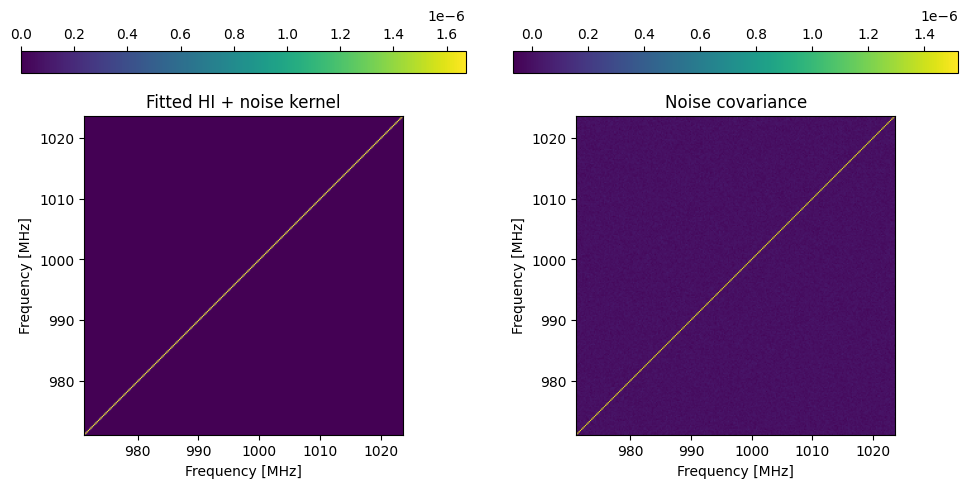

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/fg_signal_kernal_comparison_nelder_mead.pdf


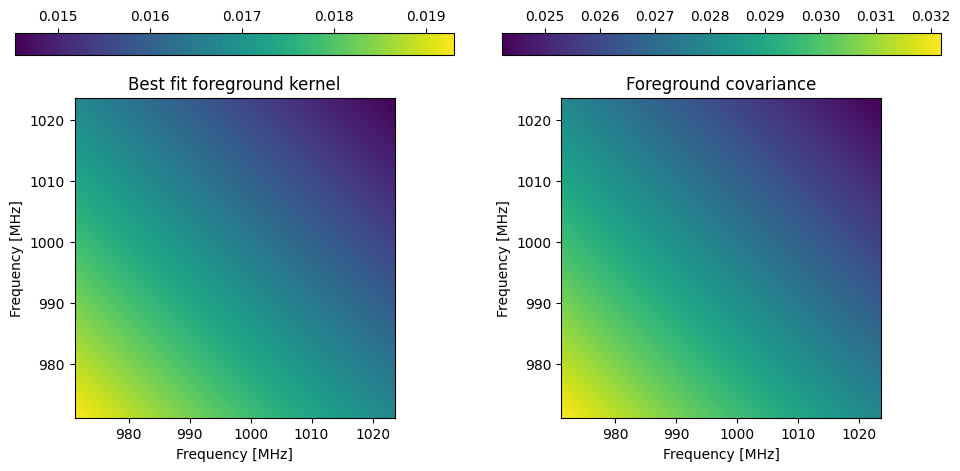

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/removed_kernal_foreground_nelder_mead.pdf
Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/removed_actual_foreground_nelder_mead.pdf


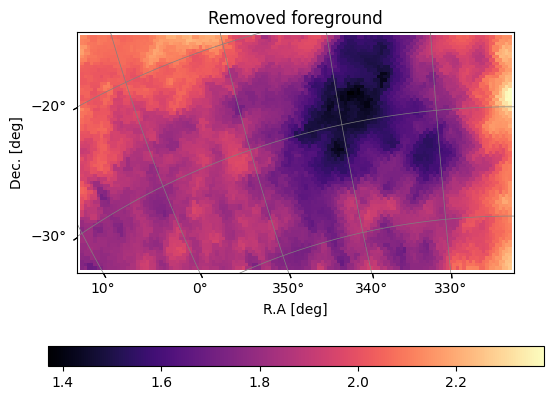

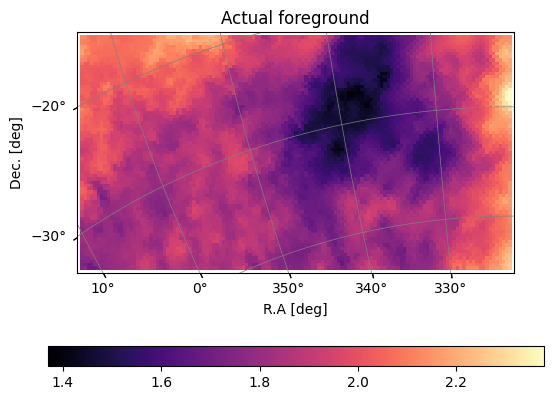

In [185]:
plot_HI_signal_kernal_comparison(fitted_pars, method = "nelder_mead", save_plot = True, week_number = 5)
plot_foreground_signal_kernal_comparison(fitted_pars, method = "nelder_mead", save_plot = True, week_number = 5)
foreground_kernal_removal_plots(fitted_pars, method = "nelder_mead", save_plot = True, week_number = 5)

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/1d_power_spectrum_nelder_mead.pdf


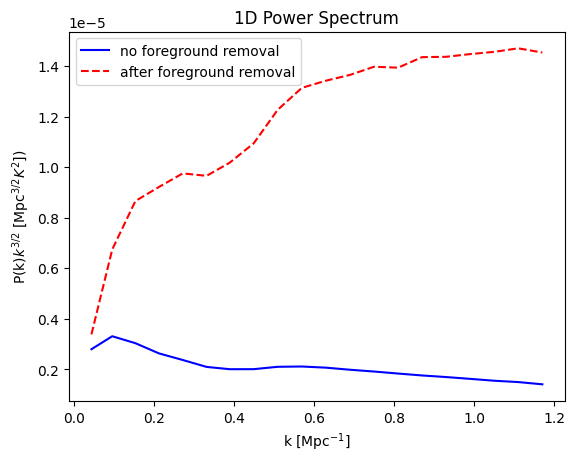

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/1d_power_spectrum_residuals_nelder_mead.pdf


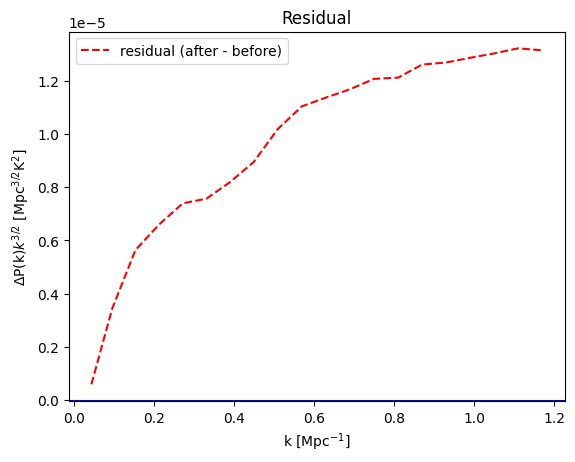

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/log_1d_power_spectrum_nelder_mead.pdf


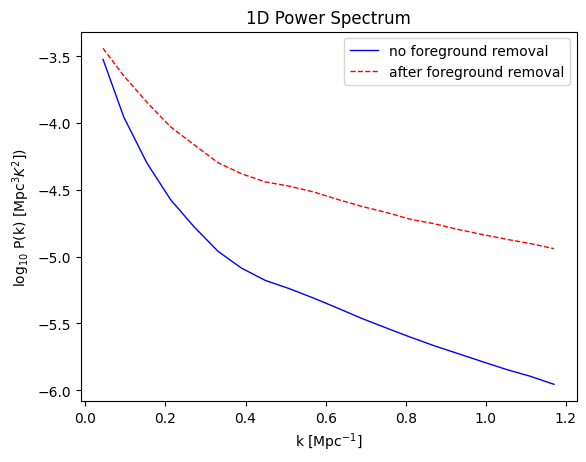

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/log_1d_power_spectrum_residuals_nelder_mead.pdf


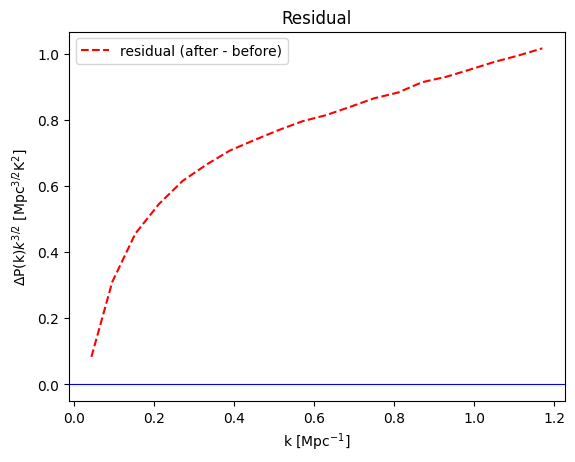

Successfully saved: /Users/gracetait/shproject/senior_honours_project/outputs/week5/cylindrical_power_spectrum_nelder_mead.pdf


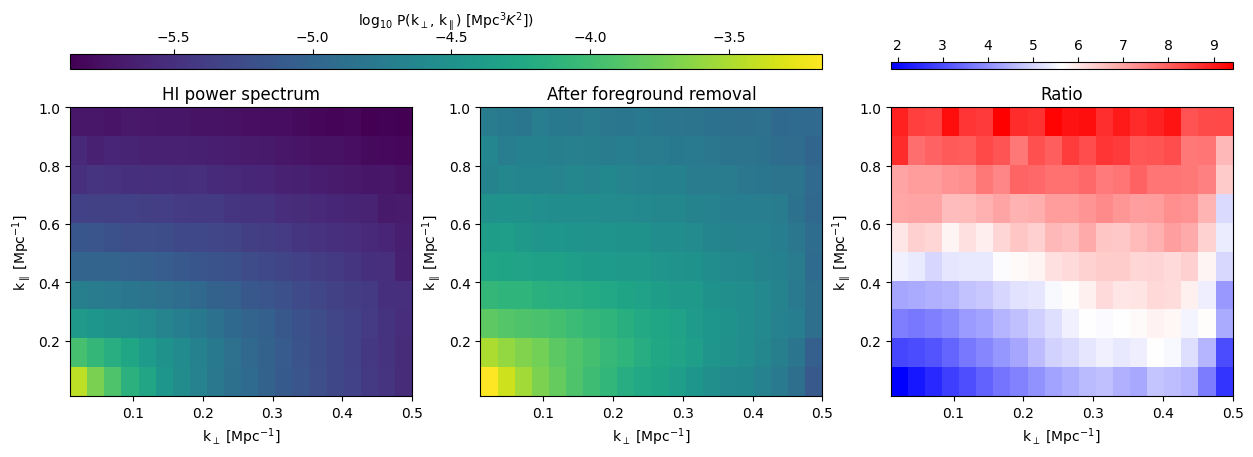

In [186]:
kernal_foreground_removal_1d_and_cylindrical_power_spectrum(fitted_pars, method = "nelder_mead", save_plot = True, week_number = 5)